# Compare CIRPIN DB to CPDB

In [26]:
import numpy as np
import pandas as pd

In [27]:
fp = '/home/ubuntu/plmCP/CPDB/tm_scores_cpdb.txt'

In [28]:
df = pd.read_csv(fp, sep=' ')

In [29]:
df_tm_cp_above05 = df[df['tmscore-CP'] > 0.5]

In [30]:
df_tm_cp_above05_diff_greater_than_0 = df_tm_cp_above05[(df_tm_cp_above05['tmscore-CP']-df_tm_cp_above05['tmscore']) > 0]

In [31]:
print(f'Number of claimed CPs: {len(df)}')
print(f'Number of pairs with same fold (above TM align 0.5 threshold): {len(df_tm_cp_above05)}')
print(f'Number of CPs confirmed by TM align (TM CP - TM > 0): {len(df_tm_cp_above05_diff_greater_than_0)}')

actual_cps = (len(df_tm_cp_above05_diff_greater_than_0))/len(df)*100
print(f'Percentage actual CPs in the database: {actual_cps}')


Number of claimed CPs: 4169
Number of pairs with same fold (above TM align 0.5 threshold): 3597
Number of CPs confirmed by TM align (TM CP - TM > 0): 3181
Percentage actual CPs in the database: 76.30127128807868


### Perform Network Analysis: How many CP clusters are there in CPDB?
### Cluster: group of redundant structures

In [ ]:
import networkx as nx

# example list of pairs
pairs = list(zip(df_tm_cp_above05_diff_greater_than_0['Protein1'], df_tm_cp_above05_diff_greater_than_0['Protein2']))

G = nx.Graph()
G.add_edges_from(pairs)

# get connected components (non-redundant groups)
clusters = list(nx.connected_components(G))
print(f'Number of CPDB clusters: {len(clusters)}')

### Save CPDB clusters

In [ ]:
import pickle
with open("CPDB_clusters.pkl", "wb") as f:
    pickle.dump(clusters, f)

### Get a representative structure from each cluster in CPDB

In [ ]:
clusters_list = [list(i) for i in clusters]
rep_structures = [i[0] for i in clusters_list]
print(len(rep_structures))
with open("CPDB_representative_structures_single_cluster.pkl", "wb") as f:
    pickle.dump(rep_structures, f)

### Retrieve these structures from the PDB

In [ ]:
import requests
from pathlib import Path

pdbs = rep_structures
# Create output directory
Path('CPDB_pdb_structures').mkdir(exist_ok=True)

for pdb_chain in pdbs:
    pdb_id = pdb_chain[:4].lower()
    chain_id = pdb_chain[4:]
    
    # Download full PDB file
    url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
    response = requests.get(url)
    
    if response.status_code == 200:
        # Filter for specific chain
        lines = response.text.split('\n')
        chain_lines = [line for line in lines 
                      if line.startswith(('ATOM', 'HETATM')) and len(line) > 21 and line[21] == chain_id]
        
        # Save to file
        with open(f'pdb_structures/{pdb_chain}.pdb', 'w') as f:
            f.write('\n'.join(chain_lines))
        
        print(f"Downloaded {pdb_chain}")
    else:
        print(f"Failed to download {pdb_id}")

In [ ]:
cirpin_fp = '/home/ubuntu/CIRPIN/scope40/cp_pairs_scope40_dedup_asym.tsv'
cirpin_db = pd.read_csv(cirpin_fp, sep= '\t')
print(f'Number of CIRPIN CP pairs: {len(cirpin_db)}') 

In [ ]:
cirpin_pairs = list(zip(cirpin_db['query'], cirpin_db['target']))

G2 = nx.Graph()
G2.add_edges_from(cirpin_pairs)

# get connected components (non-redundant groups)
cirpin_clusters = list(nx.connected_components(G2))
print(len(cirpin_clusters))

### Get a representative structure from each cluster in CIRPIN  DB

In [ ]:
c_clusters_list = [list(i) for i in cirpin_clusters]
c_rep_structures = [i[0] for i in c_clusters_list]

In [ ]:
len(c_rep_structures)

In [ ]:
import shutil
from pathlib import Path

scope40 = '/home/ubuntu/scope40/pdbstyle-2.08/'
output_dir = '/home/ubuntu/plmCP/ark_CPDB_analysis/CIRPIN_scope_structures'
Path(output_dir).mkdir(parents=True, exist_ok=True)

for pdb in c_rep_structures:
    fp = pdb + ".pdb"
    source = Path(scope40) / fp
    destination = Path(output_dir) / fp
    
    if source.exists():
        shutil.copy(source, destination)
        print(f"Copied {fp}")
    else:
        print(f"Not found: {fp}")

In [ ]:
with open("CIRPIN_SCOPe_representative_structures_single_cluster.pkl", "wb") as f:
    pickle.dump(c_rep_structures, f)

### Determine number of unique clusters in CIRPIN AFDB

In [5]:
import pandas as pd
import networkx as nx


In [2]:
cirpin_afdb = '/home/ubuntu/CIRPIN_db/verified_pairs_AFDB_cluster_reps_combined_with_CATH.txt'

In [3]:
c_afdb = pd.read_csv(cirpin_afdb, sep='\t')

In [6]:
cirpin_afdb_pairs = list(zip(c_afdb['query'], c_afdb['target']))

G3 = nx.Graph()
G3.add_edges_from(cirpin_afdb_pairs)

# get connected components (non-redundant groups)
cirpin_afdb_clusters = list(nx.connected_components(G3))
print(f'Number of CIRPIN CP clusters: {len(cirpin_afdb_clusters)}')

Number of CIRPIN CP clusters: 455


### Create dictionary of unique CPs and their CATH

In [39]:
query_cath = c_afdb.set_index('query')['cath_q'].to_dict()
target_cath = c_afdb.set_index('target')['cath_t'].to_dict()
cirpin_afdb_dict = {**query_cath, **target_cath}


### Create a new dictionary that records the CATH classification of every entry in a given cluster
### Then count how many unique CATH labels there are for each cluster, and print out the cluster with the most number of different CATH labels

In [40]:

from collections import defaultdict

cluster_caths = defaultdict(list)
for x, cluster in enumerate(cirpin_afdb_clusters):
    for pdb in cluster:
        cath = cirpin_afdb_dict[pdb]
        cluster_caths[x].append(cath)

# Count unique CATH labels per cluster
unique_counts = {cluster_id: len(set(caths)) for cluster_id, caths in cluster_caths.items()}

# Find cluster with most unique CATH labels
max_cluster = max(unique_counts, key=unique_counts.get)
print(f"Cluster {max_cluster} has {unique_counts[max_cluster]} unique CATH labels")

Cluster 0 has 292 unique CATH labels


### Save single representative structures from each cluster

In [22]:
cirpin_afdb_rep_structures_single_cluster = []

for i in cirpin_afdb_clusters:
    cirpin_afdb_rep_structures_single_cluster.append(list(i)[0])

In [25]:
import pickle 
with open("CIRPIN_afdb_representative_structures_single_cluster.pkl", "wb") as f:
    pickle.dump(cirpin_afdb_rep_structures_single_cluster, f)

### Save full list of structures per cluster

In [ ]:
cirpin_afdb_rep_structures = []

for i in cirpin_afdb_clusters:
    cirpin_afdb_rep_structures.append(i)

In [ ]:
with open("CIRPIN_afdb_representative_structures.pkl", "wb") as f:
    pickle.dump(cirpin_afdb_rep_structures, f)

### Plot Top CATH Architectures of AFDB hits

In [37]:
all_names = pd.concat([c_afdb['target'], c_afdb['query']])
unique_cps = all_names.unique()
print(f'Number of unique CPs in AFDB hits: {len(unique_cps)}')

Number of unique CPs in AFDB hits: 20138


In [42]:
unique_cps_with_CATH = {}

for i in unique_cps:
    unique_cps_with_CATH[i]=cirpin_afdb_dict[i]

In [43]:
CATH_counts = {}

for pdb, cath in unique_cps_with_CATH.items():
        if cath not in CATH_counts:
            CATH_counts[cath] = 1
        else:
            CATH_counts[cath] = CATH_counts[cath] +1

In [44]:
cath_counts_sorted = sorted(CATH_counts.items(), key=lambda item: item[1], reverse=True)
print(f'Top 10 CATH counts for unique CPs')
for i in cath_counts_sorted[0:10]:
    print(i)

Top 10 CATH counts for unique CPs
('-', 5014)
('1.10.10.10', 4605)
('1.10.10', 1128)
('3.10.20', 905)
('2.40.50.140', 781)
('3.30.160.20', 647)
('3.10.450', 580)
('3.30.70', 523)
('3.30.160', 445)
('3.30.1070', 366)


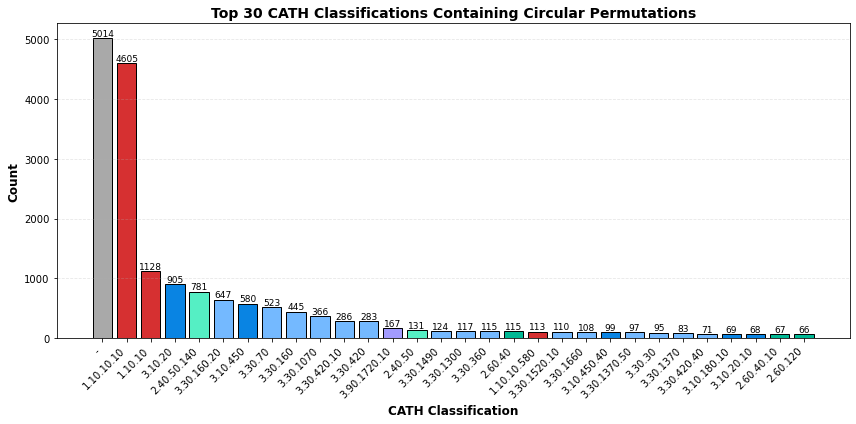

In [45]:
import matplotlib.pyplot as plt
# Separate labels and counts
labels = [item[0] for item in cath_counts_sorted[:30]]
counts = [item[1] for item in cath_counts_sorted[:30]]

def get_architecture(label):
    """Extract the first two levels (e.g., '1.10' from '1.10.10.10')"""
    if label == '-':
        return '-'
    parts = label.split('.')
    if len(parts) >= 2:
        return f"{parts[0]}.{parts[1]}"
    return label

# Create color mapping
# Create color mapping with pastel shades
architecture_colors = {
    '-': '#A9A9A9',      # Gray
    '1.10': '#d63031',   # Red
    '3.10': '#0984e3',   # Light pastel blue
    '3.30': '#74b9ff',   # Medium pastel blue
    '3.90': '#a29bfe',
    '2.40': '#55efc4',
    '2.60': '#00b894'# Green
}

# Assign colors to each bar based on architecture
bar_colors = [architecture_colors.get(get_architecture(label), 'orange') for label in labels]
#bar_colors = ['orange' for label in labels]

# Create the histogram
plt.figure(figsize=(12, 6))
plt.bar(range(len(labels)), counts, color=bar_colors, edgecolor='black')
plt.xlabel('CATH Classification', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.title('Top 30 CATH Classifications Containing Circular Permutations', fontsize=14, fontweight='bold')
plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add count labels on top of bars
for i, count in enumerate(counts):
    plt.text(i, count, str(count), ha='center', va='bottom', fontsize=9)
plt.savefig('cath_30.svg')
plt.show()

### Retrive the cluster a protein belong to

In [53]:

poi = 'AF-A0A3G6T4U0-F1-model_v4_TED03'
for i in cirpin_afdb_clusters:
    if poi in i:
        for struc in i:
            print(i)
            print(cirpin_afdb_dict[struc])
            

{'AF-A0A3G6T4U0-F1-model_v4_TED03', 'AF-A0A1W6JXE9-F1-model_v4_TED01'}
-
{'AF-A0A3G6T4U0-F1-model_v4_TED03', 'AF-A0A1W6JXE9-F1-model_v4_TED01'}
-


In [66]:
fp = '/home/ubuntu/CIRPIN_db/ark_CPDB_analysis/network_cluster_lists/CPDB_clusters.pkl'

with open(fp, 'rb') as f:
    a = pickle.load(f)

In [70]:
tot=0
for i in a:
    tot+=len(i)

In [72]:
len(a)

129